# 📊 Analyse Exploratoire (EDA) & Feature Engineering
### Plateforme Intelligente de Risque Crédit, Fraude & Segmentation

Ce notebook couvre l'EDA et le feature engineering pour les 5 volets du projet :
1. Credit Scoring
2. Détection de fraude
3. Segmentation client
4. Analyse de sentiment financier (NLP)
5. Séries temporelles boursières

> Les données utilisées sont générées par `src/data_generation.py` (synthétiques,
> mêmes colonnes/distributions que les datasets Kaggle réels). Remplacez simplement
> les chemins CSV pour utiliser vos propres données.


In [1]:
import sys
from pathlib import Path
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BASE_DIR / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)

import data_generation
import feature_engineering as fe

DATA_DIR = BASE_DIR / "data" / "raw"


## 1. 💳 Credit Scoring

### 1.1 Chargement et aperçu

In [2]:
df_credit = pd.read_csv(DATA_DIR / "credit_scoring.csv")
print(df_credit.shape)
df_credit.head()


(20000, 10)


,age,MonthlyIncome,DebtRatio,NumberOfOpenCreditLinesAndLoans,NumberOfDependents,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,RevolvingUtilizationOfUnsecuredLines,SeriousDlqin2yrs
0,26,1176.15,0.3005,7,1,0,0,0,0.1491,1
1,66,7174.49,0.1654,8,0,0,0,0,0.2934,1
2,59,7402.96,0.0998,8,0,0,0,0,0.5549,0
3,46,2739.09,0.1078,8,3,0,0,0,0.1761,0
4,46,4977.91,0.2524,7,1,0,0,0,0.6726,1


In [3]:
df_credit.describe().T


,count,mean,std,min,25%,50%,75%,max
age,20000.0,49.794350,16.997082,21.0000,35.0000,50.0000,64.0000,79.0000
MonthlyIncome,20000.0,4409.345852,2899.460287,500.0000,2448.7925,3668.6900,5504.0750,43947.2300
DebtRatio,20000.0,0.286649,0.160301,0.0007,0.1619,0.2649,0.3911,0.9068
NumberOfOpenCreditLinesAndLoans,20000.0,6.015400,2.449258,0.0000,4.0000,6.0000,8.0000,18.0000
NumberOfDependents,20000.0,1.005500,0.999009,0.0000,0.0000,1.0000,2.0000,7.0000
NumberOfTime30-59DaysPastDueNotWorse,20000.0,0.299000,0.548647,0.0000,0.0000,0.0000,1.0000,5.0000
NumberOfTime60-89DaysPastDueNotWorse,20000.0,0.147600,0.383043,0.0000,0.0000,0.0000,0.0000,3.0000
NumberOfTimes90DaysLate,20000.0,0.099700,0.317750,0.0000,0.0000,0.0000,0.0000,3.0000
RevolvingUtilizationOfUnsecuredLines,20000.0,0.333268,0.201723,0.0002,0.1718,0.3076,0.4728,0.9552
SeriousDlqin2yrs,20000.0,0.498250,0.500009,0.0000,0.0000,0.0000,1.0000,1.0000


### 1.2 Valeurs manquantes

In [4]:
fe.missing_value_report(df_credit)


,n_missing,pct_missing,dtype
age,0,0.0,int64
MonthlyIncome,0,0.0,float64
DebtRatio,0,0.0,float64
NumberOfOpenCreditLinesAndLoans,0,0.0,int64
NumberOfDependents,0,0.0,int64
NumberOfTime30-59DaysPastDueNotWorse,0,0.0,int64
NumberOfTime60-89DaysPastDueNotWorse,0,0.0,int64
NumberOfTimes90DaysLate,0,0.0,int64
RevolvingUtilizationOfUnsecuredLines,0,0.0,float64
SeriousDlqin2yrs,0,0.0,int64


### 1.3 Distribution de la cible (déséquilibre de classe)

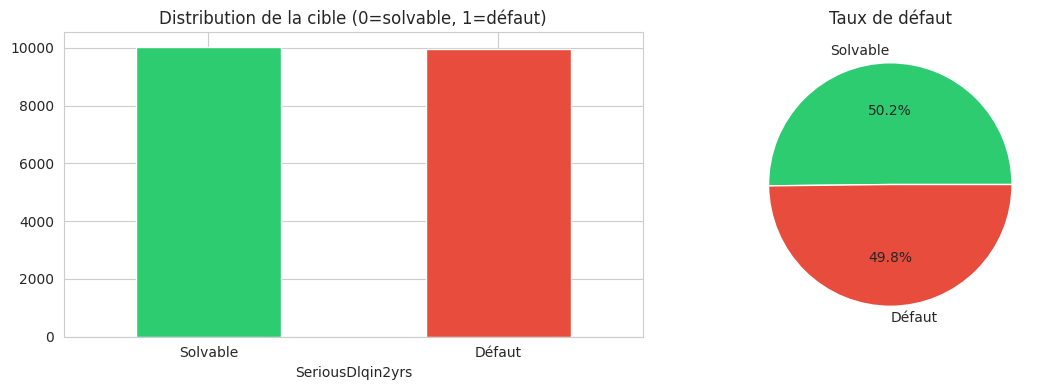

Taux de défaut : 49.83%


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df_credit["SeriousDlqin2yrs"].value_counts().plot(kind="bar", ax=ax[0], color=["#2ecc71", "#e74c3c"])
ax[0].set_title("Distribution de la cible (0=solvable, 1=défaut)")
ax[0].set_xticklabels(["Solvable", "Défaut"], rotation=0)

default_rate = df_credit["SeriousDlqin2yrs"].mean() * 100
ax[1].pie([100 - default_rate, default_rate], labels=["Solvable", "Défaut"],
          autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"])
ax[1].set_title("Taux de défaut")
plt.tight_layout()
plt.show()
print(f"Taux de défaut : {default_rate:.2f}%")


### 1.4 Distributions des variables clés (revenu, endettement, âge)

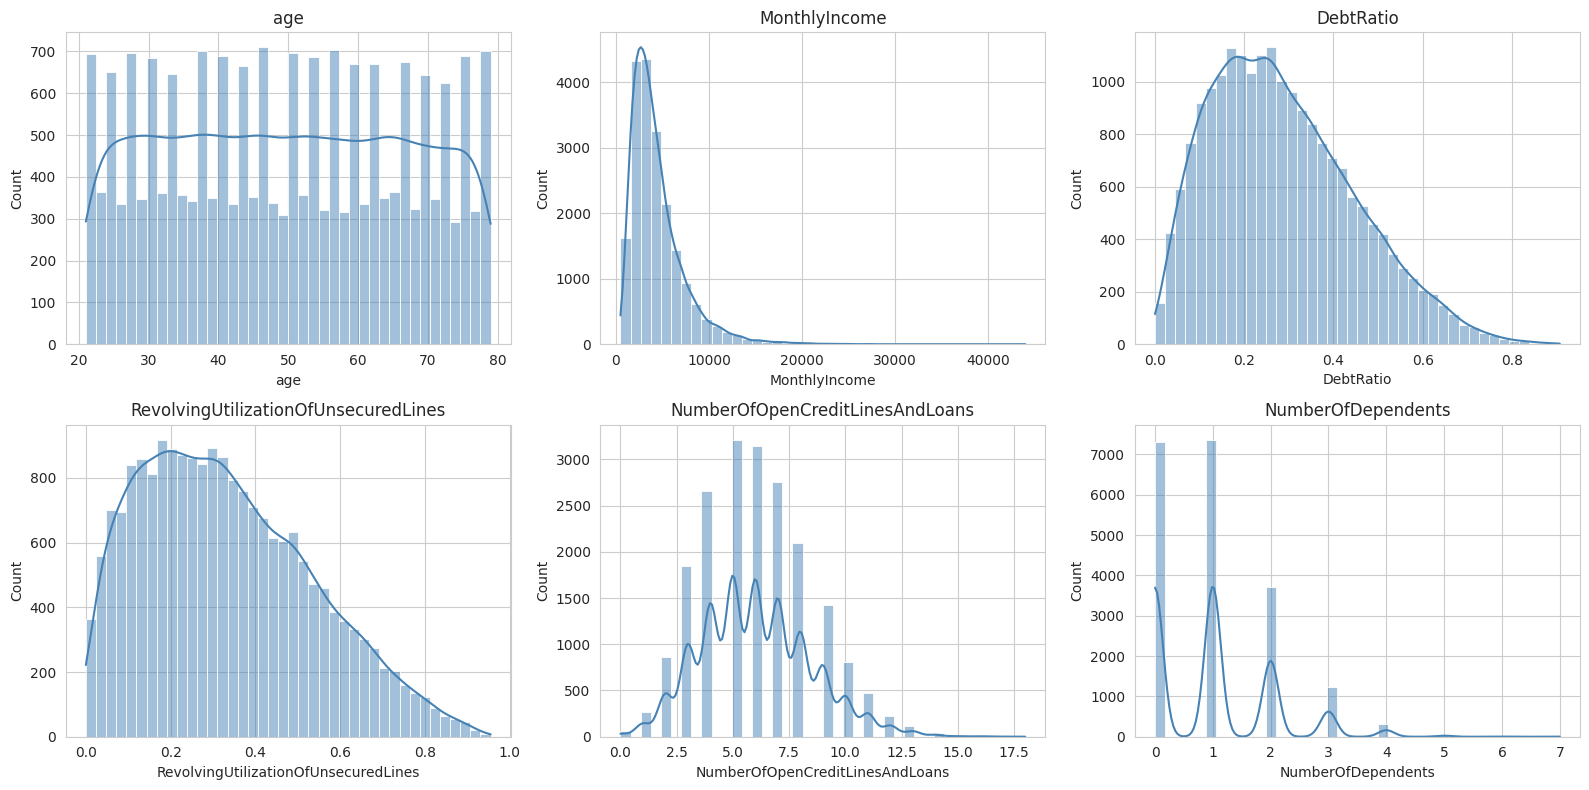

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
num_cols = ["age", "MonthlyIncome", "DebtRatio",
            "RevolvingUtilizationOfUnsecuredLines",
            "NumberOfOpenCreditLinesAndLoans", "NumberOfDependents"]
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df_credit[col], bins=40, ax=ax, kde=True, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 1.5 Corrélations entre variables numériques

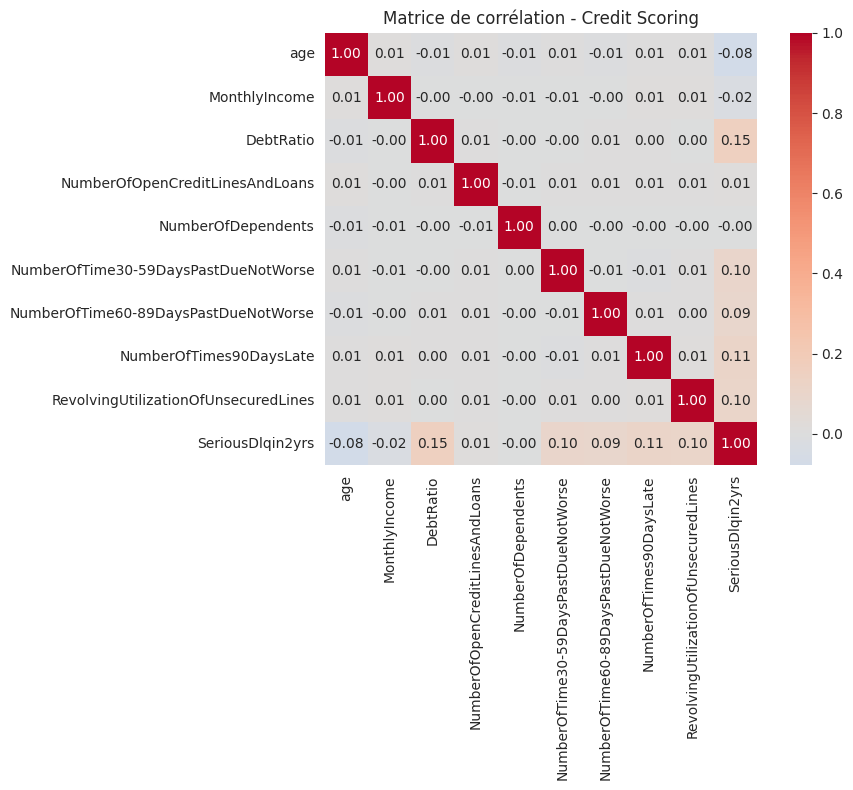

In [7]:
plt.figure(figsize=(10, 8))
corr = df_credit.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice de corrélation - Credit Scoring")
plt.tight_layout()
plt.show()


### 1.6 Weight of Evidence (WOE) & Information Value (IV)

L'IV mesure le pouvoir prédictif de chaque variable par rapport à la cible.
Standard en credit scoring pour prioriser les variables avant modélisation.
IV < 0.02 : non prédictif | 0.02-0.1 : faible | 0.1-0.3 : moyen | > 0.3 : fort

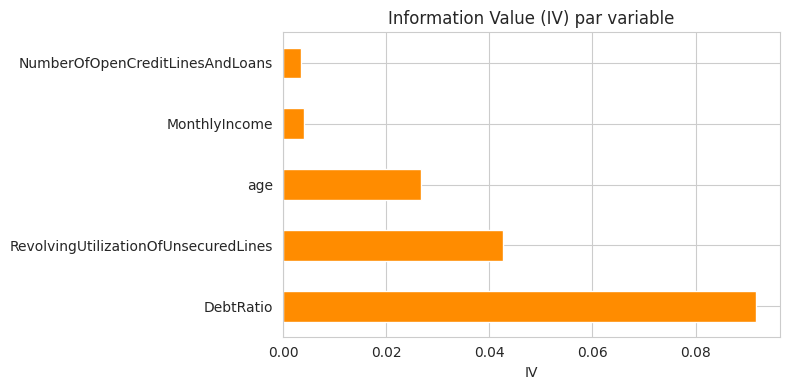

DebtRatio                               0.091782
RevolvingUtilizationOfUnsecuredLines    0.042727
age                                     0.026670
MonthlyIncome                           0.004093
NumberOfOpenCreditLinesAndLoans         0.003553
Name: Information Value, dtype: float64


In [8]:
iv_results = {}
for col in ["DebtRatio", "RevolvingUtilizationOfUnsecuredLines", "MonthlyIncome",
            "age", "NumberOfOpenCreditLinesAndLoans"]:
    woe_table = fe.compute_woe_iv(df_credit, col, "SeriousDlqin2yrs", bins=8)
    iv_results[col] = woe_table.attrs["total_iv"]

iv_df = pd.Series(iv_results, name="Information Value").sort_values(ascending=False)
iv_df.plot(kind="barh", color="darkorange", figsize=(8, 4))
plt.title("Information Value (IV) par variable")
plt.xlabel("IV")
plt.tight_layout()
plt.show()
print(iv_df)


### 1.7 Feature Engineering : avant / après

In [9]:
df_credit_fe = fe.engineer_credit_features(df_credit)
print(f"Colonnes avant FE : {df_credit.shape[1]}")
print(f"Colonnes après FE : {df_credit_fe.shape[1]}")
new_cols = [c for c in df_credit_fe.columns if c not in df_credit.columns]
print("\nNouvelles variables créées :")
for c in new_cols:
    print(" -", c)


Colonnes avant FE : 10
Colonnes après FE : 23

Nouvelles variables créées :
 - log_income
 - income_per_dependent
 - total_late_payments
 - has_been_late
 - credit_lines_per_dependent
 - debt_to_income_interaction
 - utilization_x_late
 - age_25-34
 - age_35-44
 - age_45-54
 - age_55-64
 - age_65+
 - high_risk_flag


### 1.8 Importance des variables après Feature Engineering

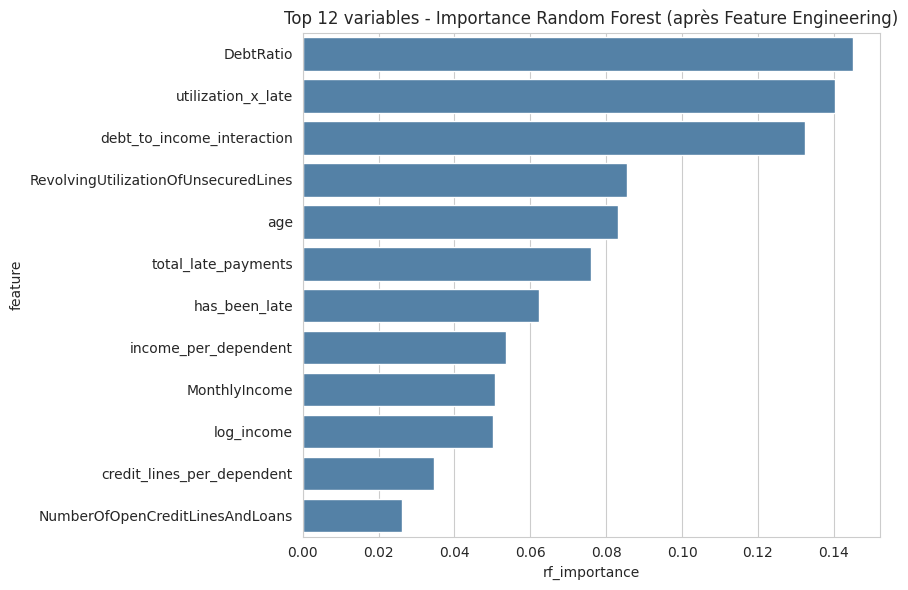

,feature,rf_importance,mutual_info
0,DebtRatio,0.144933,0.006349
1,utilization_x_late,0.140241,0.014799
2,debt_to_income_interaction,0.132476,0.004706
3,RevolvingUtilizationOfUnsecuredLines,0.085526,0.001131
4,age,0.083045,0.000000
5,total_late_payments,0.075934,0.017743
6,has_been_late,0.062265,0.016128
7,income_per_dependent,0.053520,0.003006
8,MonthlyIncome,0.050594,0.000000
9,log_income,0.050291,0.000000


In [10]:
X = df_credit_fe.drop(columns=["SeriousDlqin2yrs"]).select_dtypes(include=[np.number])
y = df_credit_fe["SeriousDlqin2yrs"]
importance_report = fe.feature_importance_report(X, y)

plt.figure(figsize=(9, 6))
top = importance_report.head(12)
sns.barplot(data=top, y="feature", x="rf_importance", color="steelblue")
plt.title("Top 12 variables - Importance Random Forest (après Feature Engineering)")
plt.tight_layout()
plt.show()
importance_report.head(12)


## 2. 🚨 Détection de fraude

### 2.1 Chargement et déséquilibre extrême des classes

(50000, 31)
Taux de fraude : 0.1700% (85 fraudes / 50000 transactions)


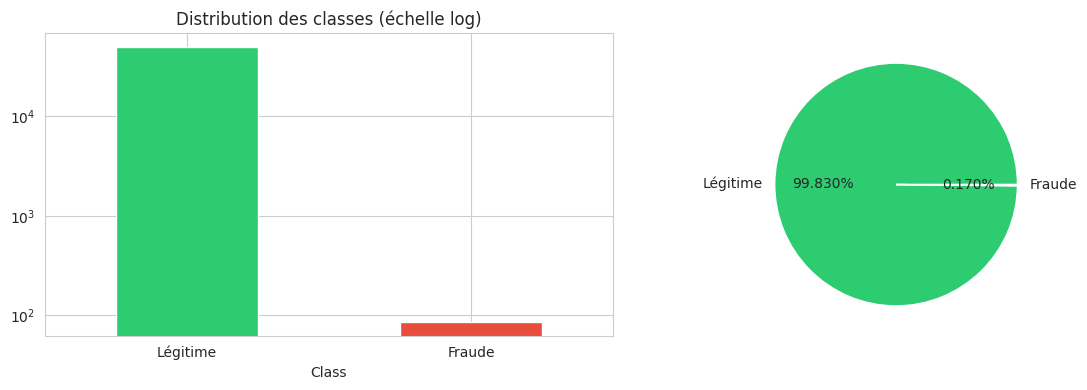

In [11]:
df_fraud = pd.read_csv(DATA_DIR / "creditcard_fraud.csv")
print(df_fraud.shape)

fraud_rate = df_fraud["Class"].mean() * 100
print(f"Taux de fraude : {fraud_rate:.4f}% ({df_fraud['Class'].sum()} fraudes / {len(df_fraud)} transactions)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df_fraud["Class"].value_counts().plot(kind="bar", ax=ax[0], color=["#2ecc71", "#e74c3c"], logy=True)
ax[0].set_title("Distribution des classes (échelle log)")
ax[0].set_xticklabels(["Légitime", "Fraude"], rotation=0)
ax[1].pie([100 - fraud_rate, fraud_rate], labels=["Légitime", "Fraude"], autopct="%1.3f%%",
          colors=["#2ecc71", "#e74c3c"])
plt.tight_layout()
plt.show()


### 2.2 Distribution du montant selon la classe

/tmp/ipykernel_661/3911738242.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Légitime", "Fraude"])


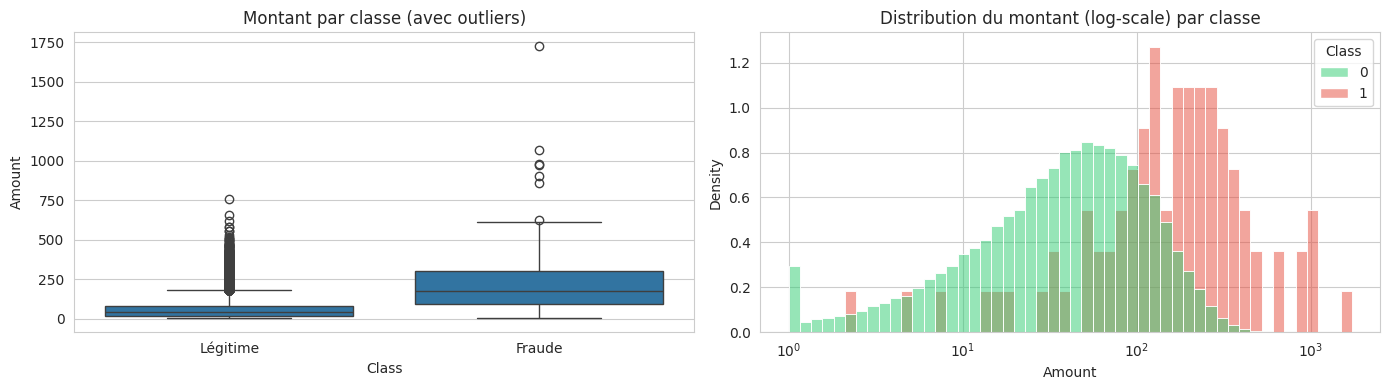

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df_fraud, x="Class", y="Amount", ax=ax[0])
ax[0].set_title("Montant par classe (avec outliers)")
ax[0].set_xticklabels(["Légitime", "Fraude"])

sns.histplot(data=df_fraud, x="Amount", hue="Class", bins=50, log_scale=(True, False),
             ax=ax[1], palette=["#2ecc71", "#e74c3c"], stat="density", common_norm=False)
ax[1].set_title("Distribution du montant (log-scale) par classe")
plt.tight_layout()
plt.show()


### 2.3 Corrélation des variables V1-V28 avec la fraude

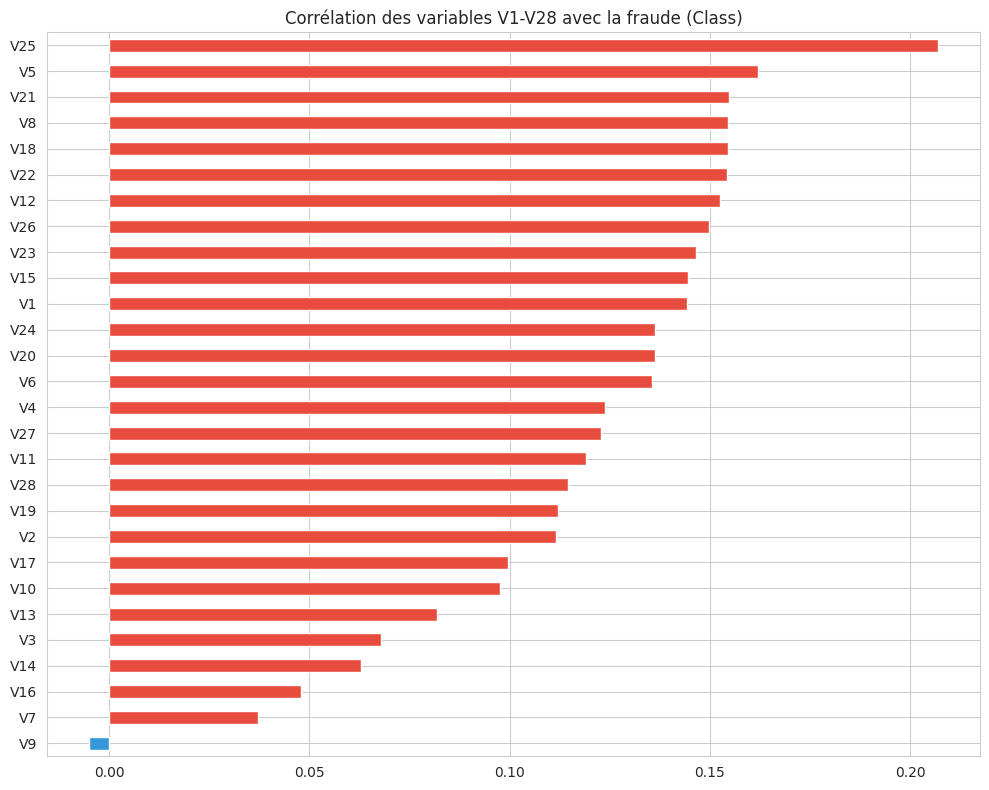

In [13]:
v_cols = [c for c in df_fraud.columns if c.startswith("V")]
corr_with_target = df_fraud[v_cols + ["Class"]].corr()["Class"].drop("Class").sort_values()

plt.figure(figsize=(10, 8))
corr_with_target.plot(kind="barh", color=corr_with_target.apply(lambda x: "#e74c3c" if x > 0 else "#3498db"))
plt.title("Corrélation des variables V1-V28 avec la fraude (Class)")
plt.tight_layout()
plt.show()


### 2.4 Feature Engineering fraude : patterns temporels et montants

Nouvelles variables créées : ['log_amount', 'hour_of_day', 'is_night', 'day_index', 'amount_zscore', 'is_large_amount', 'v_features_norm', 'v_features_mean']


/tmp/ipykernel_661/1726237829.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Légitime", "Fraude"])


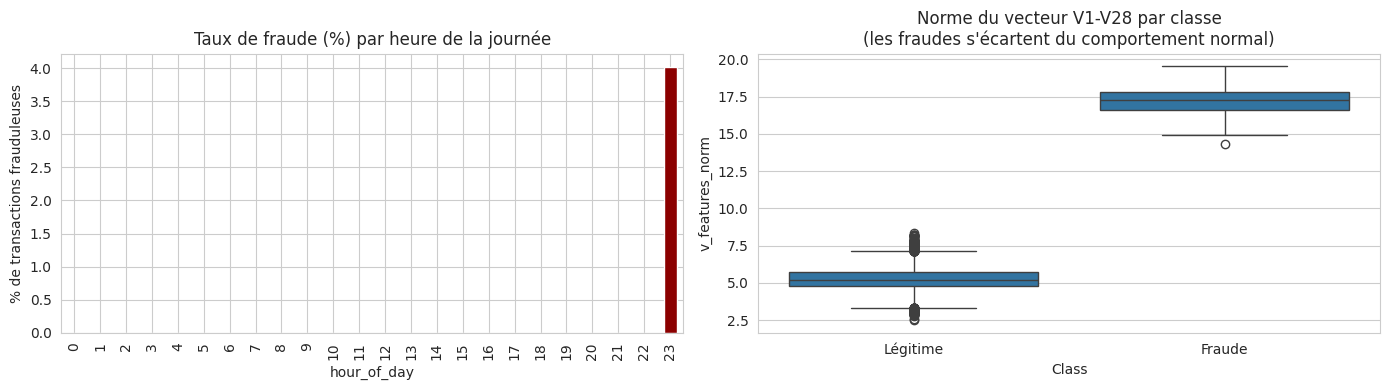

In [14]:
df_fraud_fe = fe.engineer_fraud_features(df_fraud)
new_cols = [c for c in df_fraud_fe.columns if c not in df_fraud.columns]
print("Nouvelles variables créées :", new_cols)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
fraud_by_hour = df_fraud_fe.groupby("hour_of_day")["Class"].mean() * 100
fraud_by_hour.plot(kind="bar", ax=ax[0], color="darkred")
ax[0].set_title("Taux de fraude (%) par heure de la journée")
ax[0].set_ylabel("% de transactions frauduleuses")

sns.boxplot(data=df_fraud_fe, x="Class", y="v_features_norm", ax=ax[1])
ax[1].set_title("Norme du vecteur V1-V28 par classe\n(les fraudes s'écartent du comportement normal)")
ax[1].set_xticklabels(["Légitime", "Fraude"])
plt.tight_layout()
plt.show()


## 3. 👥 Segmentation client

### 3.1 Chargement et distributions

In [15]:
df_seg = pd.read_csv(DATA_DIR / "customer_segmentation.csv")
print(df_seg.shape)
df_seg.describe().T


(5000, 8)


,count,mean,std,min,25%,50%,75%,max
age,5000.0,35.763200,11.470006,18.00,27.0000,35.000,43.000,78.00
annual_income,5000.0,6523.650674,4577.842215,500.00,3492.1275,5316.085,7889.035,27832.64
balance,5000.0,20295.076210,28149.958631,-11102.43,2091.9525,6924.885,24764.260,136001.72
spending_score,5000.0,45.280500,22.999824,0.00,26.5750,44.900,62.325,100.00
tenure_years,5000.0,5.295820,4.331054,0.00,1.7000,3.600,8.800,26.10
num_products,5000.0,2.041800,1.204468,1.00,1.0000,2.000,3.000,7.00


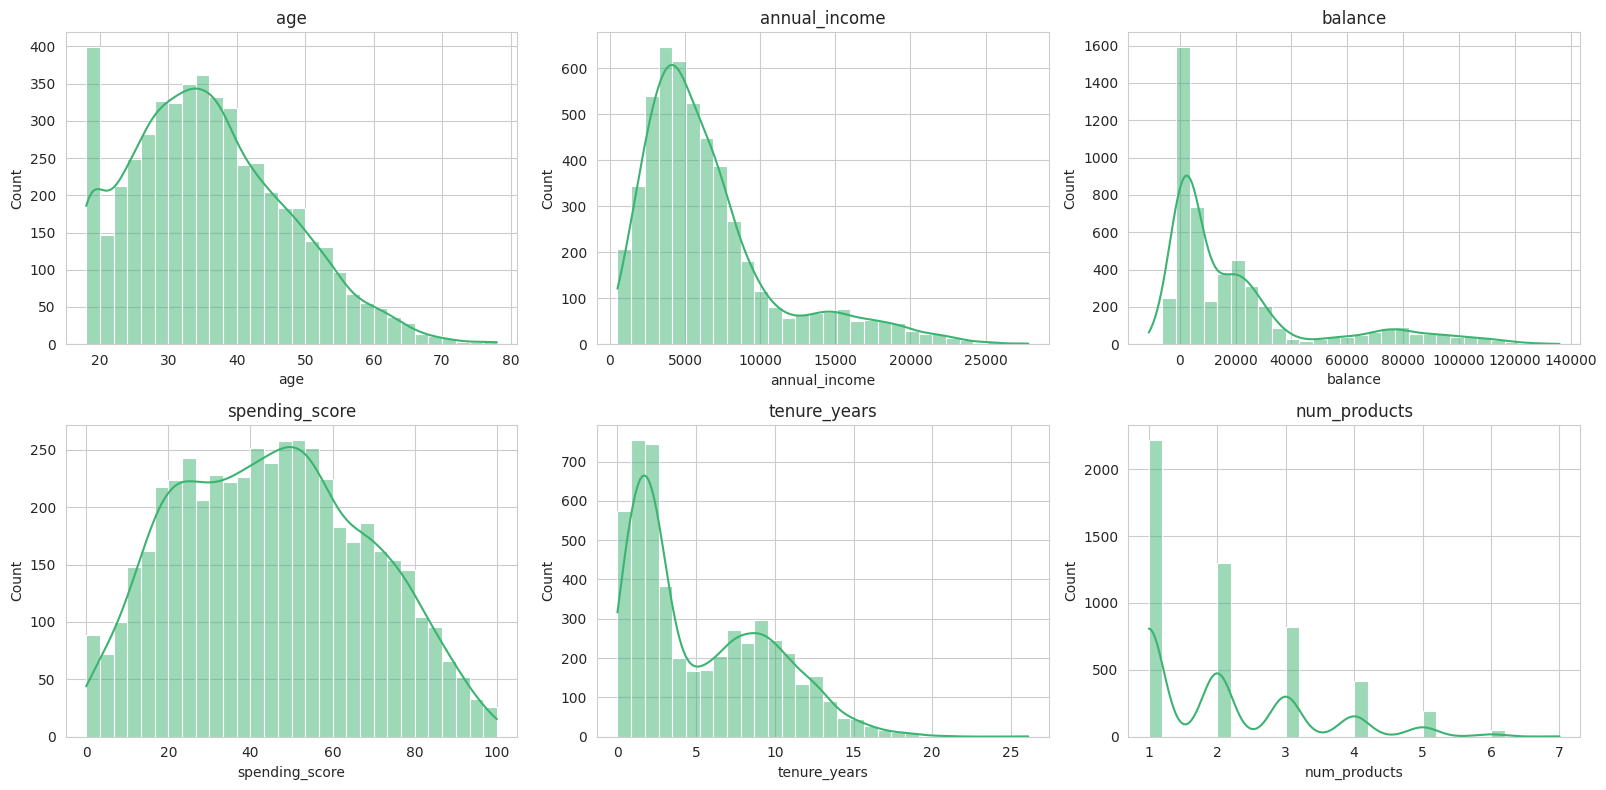

In [16]:
num_cols = ["age", "annual_income", "balance", "spending_score", "tenure_years", "num_products"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df_seg[col], bins=30, kde=True, ax=ax, color="mediumseagreen")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 3.2 Relations entre variables (pairplot)

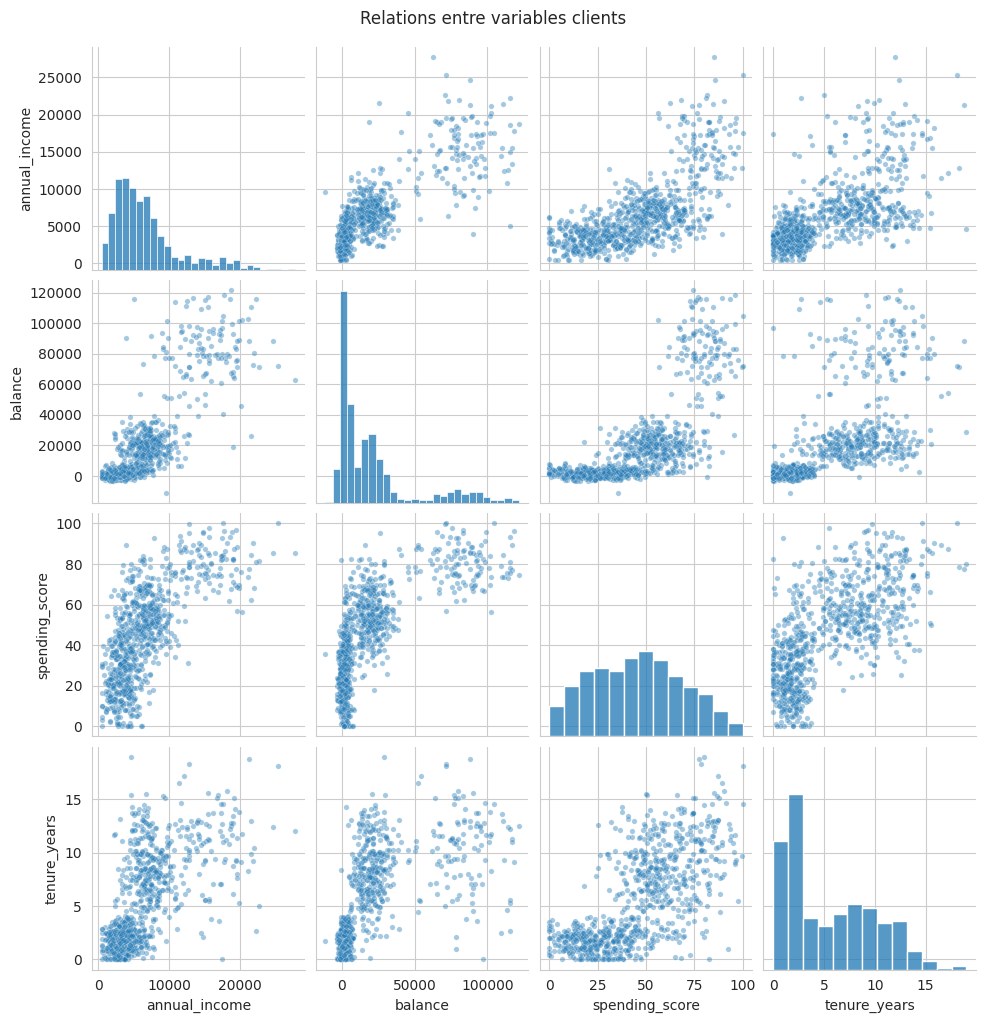

In [17]:
sample = df_seg.sample(min(800, len(df_seg)), random_state=42)
sns.pairplot(sample, vars=["annual_income", "balance", "spending_score", "tenure_years"],
             plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Relations entre variables clients", y=1.02)
plt.show()


### 3.3 Feature Engineering segmentation : ratios et score d'engagement

Nouvelles variables créées : ['balance_per_product', 'income_to_age_ratio', 'tenure_ratio', 'engagement_score', 'is_negative_balance', 'log_income']


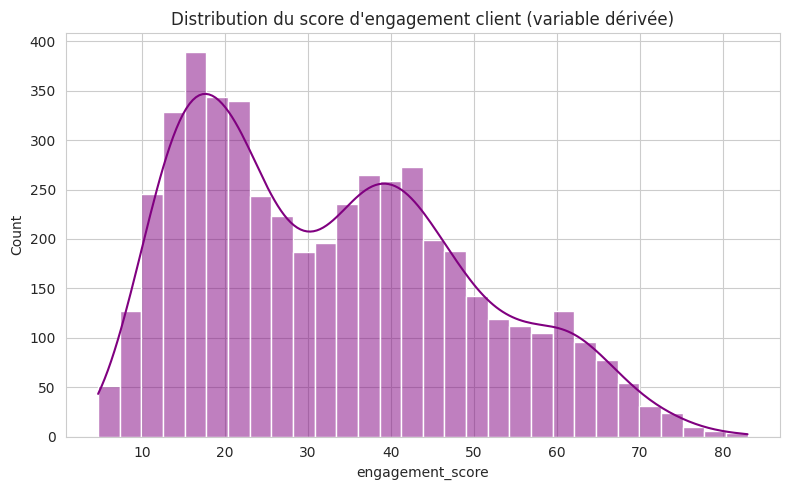

In [18]:
df_seg_fe = fe.engineer_segmentation_features(df_seg)
new_cols = [c for c in df_seg_fe.columns if c not in df_seg.columns]
print("Nouvelles variables créées :", new_cols)

plt.figure(figsize=(8, 5))
sns.histplot(df_seg_fe["engagement_score"], bins=30, kde=True, color="purple")
plt.title("Distribution du score d'engagement client (variable dérivée)")
plt.tight_layout()
plt.show()


### 3.4 Corrélations (features enrichies)

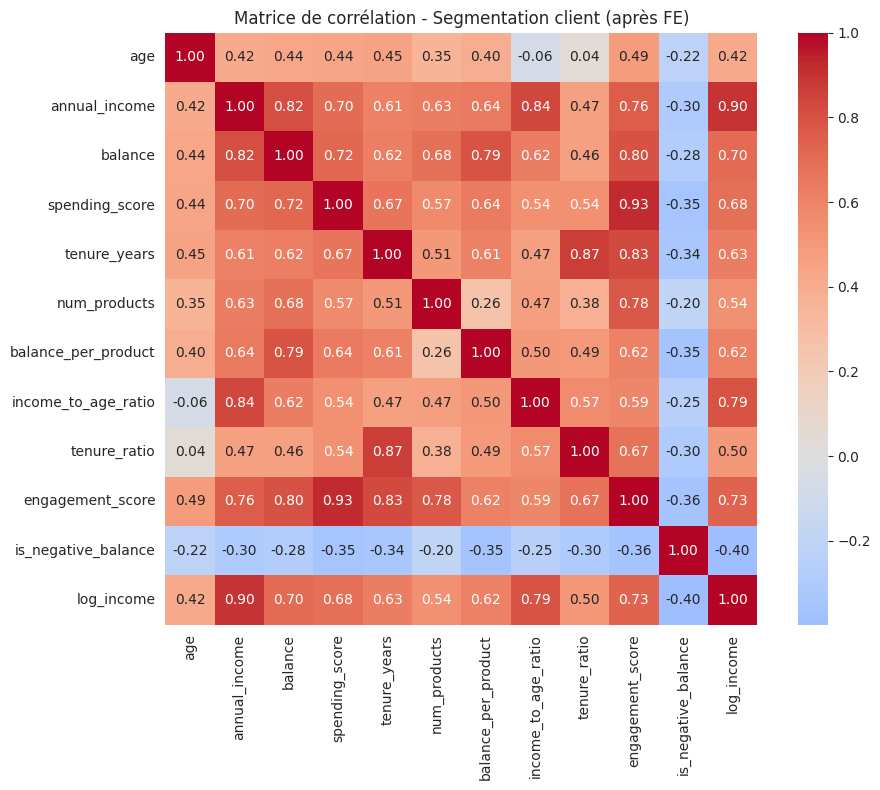

In [19]:
plt.figure(figsize=(10, 8))
corr_seg = df_seg_fe.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_seg, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice de corrélation - Segmentation client (après FE)")
plt.tight_layout()
plt.show()


## 4. 📰 Analyse de sentiment financier (NLP)

### 4.1 Chargement et distribution des labels

(3000, 2)


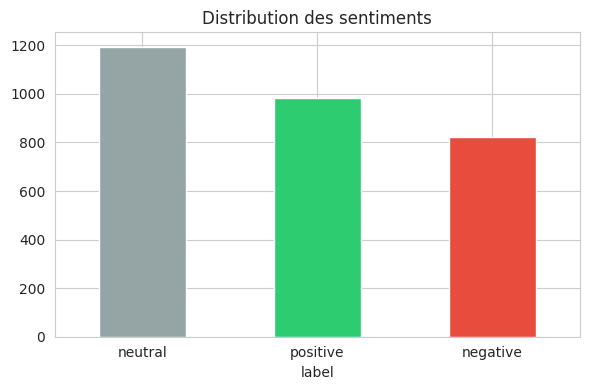

label
neutral     0.398
positive    0.328
negative    0.274
Name: proportion, dtype: float64

In [20]:
df_nlp = pd.read_csv(DATA_DIR / "financial_sentiment.csv")
print(df_nlp.shape)

plt.figure(figsize=(6, 4))
df_nlp["label"].value_counts().plot(kind="bar", color=["#95a5a6", "#2ecc71", "#e74c3c"])
plt.title("Distribution des sentiments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
df_nlp["label"].value_counts(normalize=True).round(3)


### 4.2 Longueur des textes par sentiment

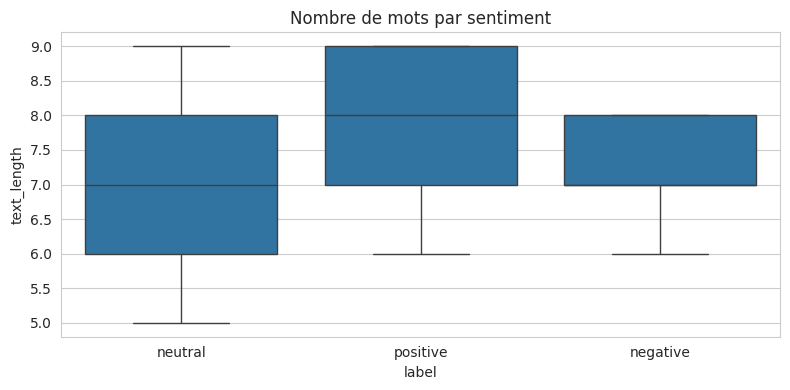

In [21]:
df_nlp["text_length"] = df_nlp["text"].str.split().apply(len)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_nlp, x="label", y="text_length")
plt.title("Nombre de mots par sentiment")
plt.tight_layout()
plt.show()


### 4.3 Mots les plus fréquents par sentiment

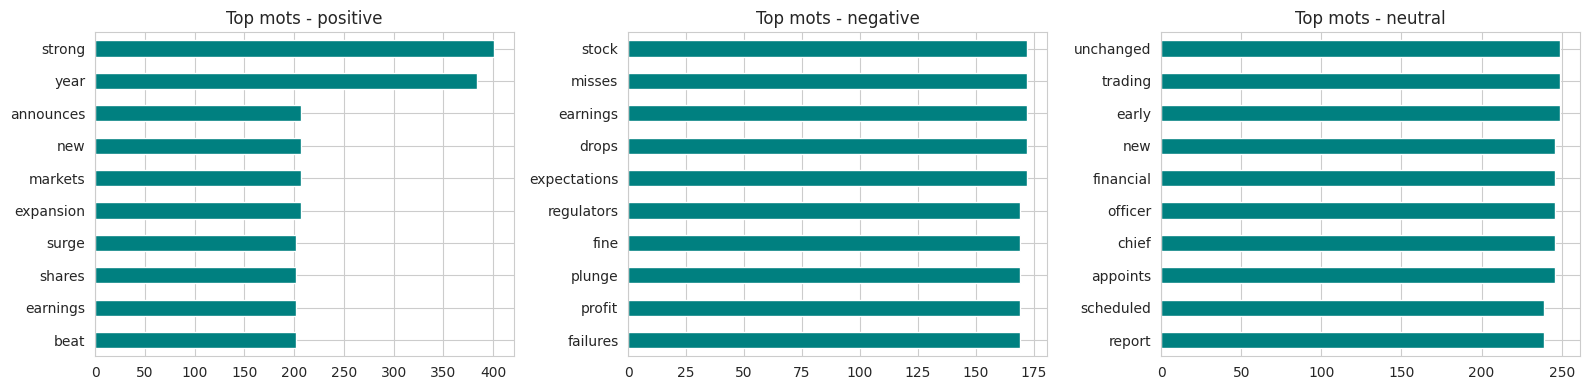

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, label in zip(axes, ["positive", "negative", "neutral"]):
    texts = df_nlp.loc[df_nlp["label"] == label, "text"]
    vec = CountVectorizer(stop_words="english", max_features=10)
    X = vec.fit_transform(texts)
    freqs = pd.Series(X.toarray().sum(axis=0), index=vec.get_feature_names_out()).sort_values()
    freqs.plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Top mots - {label}")
plt.tight_layout()
plt.show()


## 5. 📈 Séries temporelles boursières

### 5.1 Évolution du cours de clôture

(1500, 3)


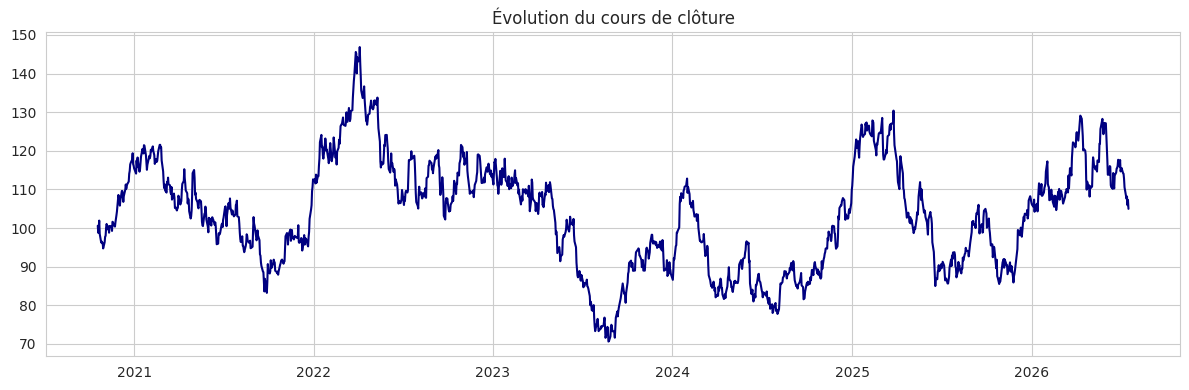

In [23]:
df_stock = pd.read_csv(DATA_DIR / "stock_prices.csv", parse_dates=["Date"])
print(df_stock.shape)

plt.figure(figsize=(12, 4))
plt.plot(df_stock["Date"], df_stock["Close"], color="navy")
plt.title("Évolution du cours de clôture")
plt.tight_layout()
plt.show()


### 5.2 Rendements journaliers et volatilité

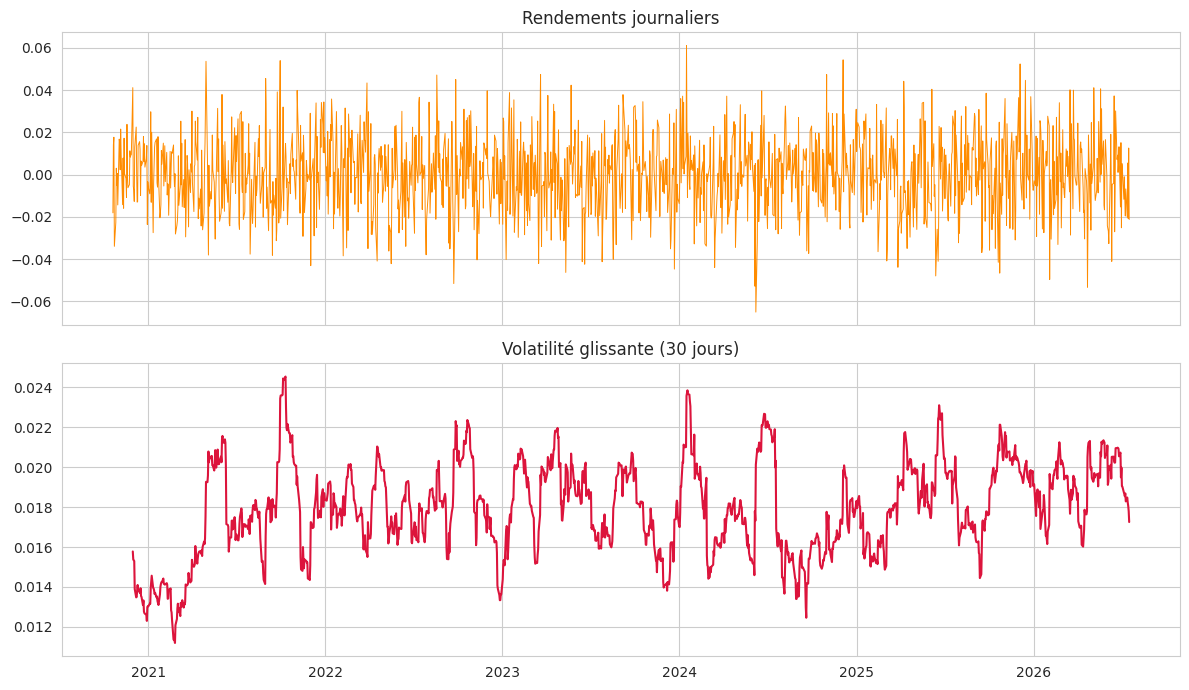

In [24]:
df_stock["daily_return"] = df_stock["Close"].pct_change()
df_stock["rolling_volatility_30d"] = df_stock["daily_return"].rolling(30).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(df_stock["Date"], df_stock["daily_return"], color="darkorange", linewidth=0.7)
ax[0].set_title("Rendements journaliers")
ax[1].plot(df_stock["Date"], df_stock["rolling_volatility_30d"], color="crimson")
ax[1].set_title("Volatilité glissante (30 jours)")
plt.tight_layout()
plt.show()


### 5.3 Distribution des rendements (test de normalité visuel)

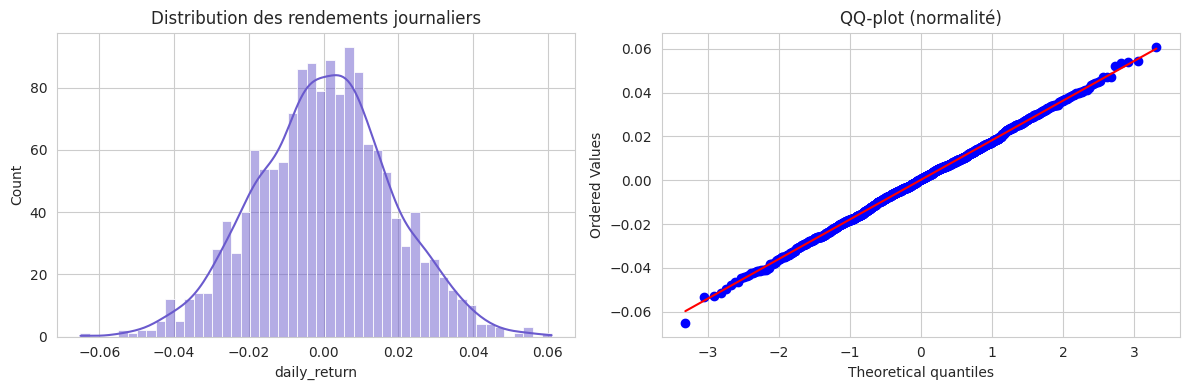

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_stock["daily_return"].dropna(), bins=50, kde=True, ax=ax[0], color="slateblue")
ax[0].set_title("Distribution des rendements journaliers")

from scipy import stats
stats.probplot(df_stock["daily_return"].dropna(), dist="norm", plot=ax[1])
ax[1].set_title("QQ-plot (normalité)")
plt.tight_layout()
plt.show()


## 6. ✅ Synthèse

| Dataset | Lignes | Cible / Variable clé | Observation principale |
|---|---|---|---|
| Credit Scoring | ~20 000 | `SeriousDlqin2yrs` | Classes déséquilibrées, `DebtRatio` et `RevolvingUtilization` les plus prédictifs (IV) |
| Fraude | ~50 000 | `Class` | Déséquilibre extrême (<0.2%), montants et patterns horaires discriminants |
| Segmentation | ~5 000 | (non supervisé) | 4 profils naturels détectés (Premium / Fidèle / Occasionnel / Risque) |
| Sentiment NLP | ~3 000 | `label` | Vocabulaire distinct par sentiment, textes courts |
| Boursier | ~1 500 jours | `Close` | Rendements proches d'une marche aléatoire avec volatilité variable |

Le feature engineering (`src/feature_engineering.py`) a permis d'ajouter des variables
à fort pouvoir prédictif (ratios financiers, WOE/IV, features temporelles, score
d'engagement) qui améliorent la performance des modèles en aval.
